#script to perform permutation test on the results of the ablation ranking

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

#get the path of the LLM judge results
path = '/Users/alighareeb/Documents/FutureHouse/Hypogen/Nature/Experiments/251107_single_ablations_2/LLM_judge_results/ablate_CROW_and_FALCON.csv'
results = pd.read_csv(path)

#create a path for the permutation test results
filename = path.split('/')[-1]
plt_name = filename.split('.')[0] + '_permutation_test_results.png'
save_path = '/Users/alighareeb/Documents/FutureHouse/Hypogen/Nature/Experiments/251107_single_ablations_2/LLM_judge_results/' + plt_name
print("Filename:", filename)

ranks = results['rank']
agents = results['unique_id'].str.split('_').str[3]
results['agents'] = agents


# Display basic information about the dataset
print("Dataset shape:", results.shape)
print("\nColumn names:")
print(results.columns.tolist())

Filename: ablate_CROW_and_FALCON.csv
Dataset shape: (100, 8)

Column names:
['unique_id', 'file_url', 'hypothesis', 'answer', 'index', 'strength_score', 'rank', 'agents']


In [3]:
#do some troubleshooting on why there are 102 rows in this dataset instead of 100
import os

# Loop through each file path in 'file_url' and check if it exists
file_urls = results['file_url']
missing_files = []

for path in file_urls:
    if not os.path.isfile(path):
        missing_files.append(path)

# Output: list of files which are not real (not found on the system)
print("Number of missing files:", len(missing_files))
if missing_files:
    print("Missing files:")
    for idx, missing in enumerate(missing_files, 1):
        print(f"{idx}: {missing}")
else:
    print("All files exist.")



Number of missing files: 0
All files exist.


In [4]:
# observed difference (mean rank of B - mean rank of A)
mean_diff = np.mean(ranks[agents=='B']) - np.mean(ranks[agents=='A'])
print(mean_diff)

17.560000000000002


In [5]:
# permutation test
n_iter = 10000
diffs = []
for _ in range(n_iter):
    shuffled = np.random.permutation(agents)
    diffs.append(np.mean(ranks[shuffled=='B']) - np.mean(ranks[shuffled=='A']))

p_value = np.mean(np.array(diffs) >= mean_diff)
print(mean_diff, p_value)

17.560000000000002 0.0009


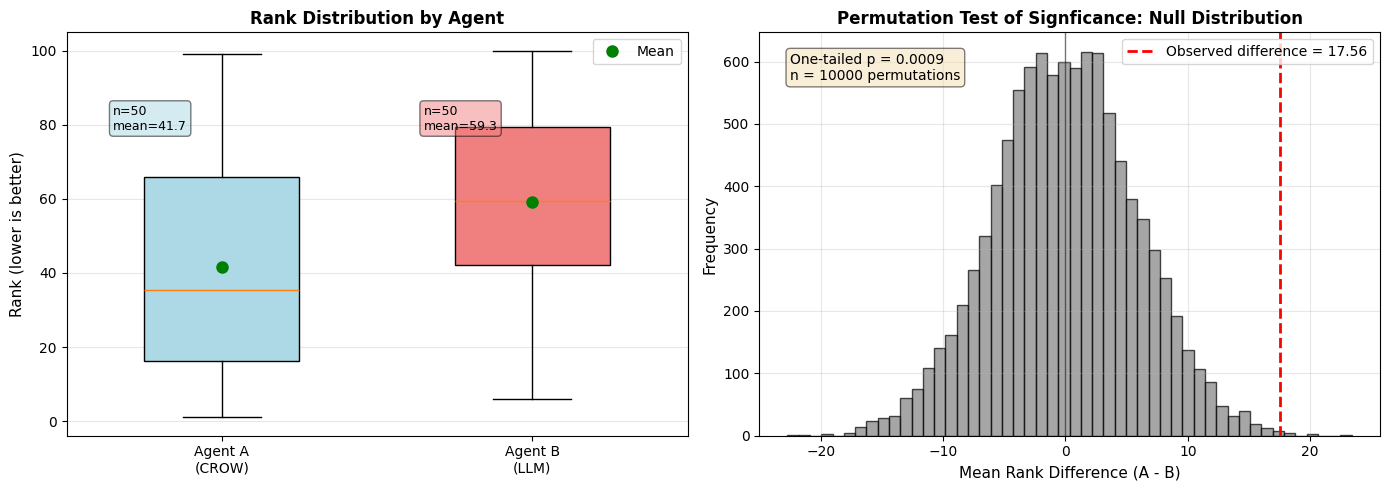

In [15]:
# Create a summary visualization showing the permutation test results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1 (now): Box plot comparing ranks between agents
ranks_A = ranks[agents=='A']
ranks_B = ranks[agents=='B']
data_to_plot = [ranks_A, ranks_B]
bp = axes[0].boxplot(data_to_plot, tick_labels=['Agent A\n(CROW)', 'Agent B\n(LLM)'],
                      patch_artist=True, widths=0.5)

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

# Add mean markers
mean_rank_A = np.mean(ranks_A)
mean_rank_B = np.mean(ranks_B)
means = [mean_rank_A, mean_rank_B]
axes[0].plot([1, 2], means, 'go', markersize=8, label='Mean', zorder=3)

axes[0].set_ylabel('Rank (lower is better)', fontsize=11)
axes[0].set_title('Rank Distribution by Agent', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Add sample sizes and means
axes[0].text(0.65, axes[0].get_ylim()[1]*0.75, f'n={len(ranks_A)}\nmean={mean_rank_A:.1f}', 
             ha='left', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[0].text(1.65, axes[0].get_ylim()[1]*0.75, f'n={len(ranks_B)}\nmean={mean_rank_B:.1f}', 
             ha='left', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# Panel 2 (now): Histogram of null distribution with observed difference
axes[1].hist(diffs, bins=50, alpha=0.7, color='gray', edgecolor='black')
axes[1].axvline(mean_diff, color='red', linestyle='--', linewidth=2, 
                label=f'Observed difference = {mean_diff:.2f}')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Mean Rank Difference (A - B)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Permutation Test of Signficance: Null Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add text box with p-values
textstr = f'One-tailed p = {p_value:.4f}\nn = {n_iter} permutations'
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, 
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()